In [1]:
import numpy as np
from scipy.stats import norm
# from cmblensplus/utils/
import constant as c
# others
import local
import tools_multitracer as mass
import tools_delens
import tools_cmb
from matplotlib.pyplot import *
cr = rcParams['axes.prop_cycle'].by_key()['color']

In [2]:
import importlib
importlib.reload(tools_delens)

<module 'tools_delens' from '/global/u1/t/toshiyan/Work/Ongoing/litebird/project-lens/tools_delens.py'>

In [6]:
lmax = 190

In [13]:
pobj = local.analysis()
ls = np.linspace(0,lmax,lmax+1)
nlfg = pobj.clfg[:lmax+1]
rBB = pobj.tcl[2,:lmax+1]
lBB = pobj.lBB[:lmax+1]
Nl = np.ones(lmax+1)*(2*np.pi/10800./2.72e6)**2

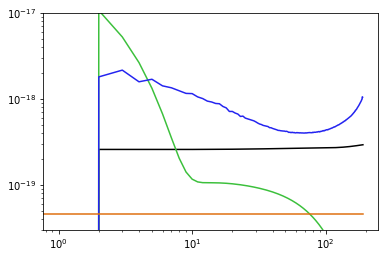

In [17]:
ylim(3e-20,1e-17)
loglog(ls,lBB,color='k')
loglog(ls,.005*rBB,color='C2')
loglog(ls[:190],nlfg[:190])
loglog(ls,Nl)

In [18]:
def frr(r,lbmin,lbmax,Alens):
    return np.sum((ls[lbmin:lbmax+1]+.5)*(rBB[lbmin:lbmax+1]/(r*rBB[lbmin:lbmax+1]+Alens*pobj.lBB[lbmin:lbmax+1]+nlfg[lbmin:lbmax+1]))**2)

In [23]:
def frr0(r,lbmin,lbmax,Alens):
    return np.sum((ls[lbmin:lbmax+1]+.5)*(rBB[lbmin:lbmax+1]/(r*rBB[lbmin:lbmax+1]+Alens*pobj.lBB[lbmin:lbmax+1]+Nl[lbmin:lbmax+1]))**2)

In [26]:
rs = np.arange(0.,1e-2,1e-5)
sigr = np.zeros(len(rs))
Sigr = np.zeros(len(rs))
sigr0 = np.zeros(len(rs))
Sigr0 = np.zeros(len(rs))

In [27]:
for i, r in enumerate(rs):
    sigr[i] = 1./np.sqrt(frr(r,2,lmax,1.))
    Sigr[i] = 1./np.sqrt(frr(r,2,lmax,.5))
    sigr0[i] = 1./np.sqrt(frr0(r,2,lmax,1.))
    Sigr0[i] = 1./np.sqrt(frr0(r,2,lmax,.5))

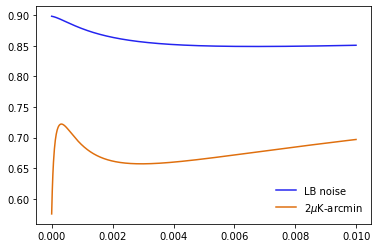

In [29]:
plot(rs,Sigr/sigr,label='LB noise')
plot(rs,Sigr0/sigr0,label=r'$2\mu$K-arcmin')
legend()